In [1]:
import mmpose
from mmpose.apis import inference_topdown, init_model
from IPython.display import display, Image
import pathlib
import cv2
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from mmpose.registry import VISUALIZERS
from mmpose.structures import merge_data_samples
import tqdm.notebook as tqdm
from enum import Enum

/home/gleb/miniconda3/envs/openmmlab/lib/python3.8/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


In [2]:
dataset_path = pathlib.Path("hand dance")

In [3]:
def show_video(path: str, process_frame_func=None):
    video = cv2.VideoCapture(path)
    display_handle=display(None, display_id=True)
    
    try:
        while True:
            start = time.time()
            _, frame = video.read()
            if process_frame_func is not None:
                frame = process_frame_func(frame)
            _, frame = cv2.imencode('.jpeg', frame)
            end = time.time()
            fps = 1/(end-start)
            display_handle.update(Image(data=frame.tobytes()))
    except:
        pass
    finally:
        video.release()
        display_handle.update(None)

In [4]:
config_path = "../configs/hand_3d_keypoint/internet/interhand3d/internet_res50_4xb16-20e_interhand3d-256x256.py"
checkpoint_path = "https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth"

model_hand = init_model(config_path, checkpoint_path, device="cuda:0")

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth


/home/gleb/miniconda3/envs/openmmlab/lib/python3.8/site-packages/mmpose/datasets/datasets/utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/interhand3d.py" does not exist. A matched config file "/home/gleb/miniconda3/envs/openmmlab/lib/python3.8/site-packages/mmpose/.mim/configs/_base_/datasets/interhand3d.py" will be used instead.
  warnings.warn(


In [5]:
config_path = "../configs/body_2d_keypoint/topdown_heatmap/coco/td-hm_hrnet-w48_8xb32-210e_coco-256x192.py"
checkpoint_path = "https://download.openmmlab.com/mmpose/top_down/hrnet/hrnet_w48_coco_256x192-b9e0b3ab_20200708.pth"

model_pose = init_model(config_path, checkpoint_path, device="cuda:0")
model_pose = model_pose.to("cuda:0")

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/top_down/hrnet/hrnet_w48_coco_256x192-b9e0b3ab_20200708.pth


/home/gleb/miniconda3/envs/openmmlab/lib/python3.8/site-packages/mmpose/datasets/datasets/utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/coco.py" does not exist. A matched config file "/home/gleb/miniconda3/envs/openmmlab/lib/python3.8/site-packages/mmpose/.mim/configs/_base_/datasets/coco.py" will be used instead.
  warnings.warn(


In [7]:
# Выбор видео

CLASS = "3"
VIDEO_IDX = 4

video_path = list((dataset_path / CLASS).glob("*"))[VIDEO_IDX]
print(video_path)
video = cv2.VideoCapture(video_path)
_, img = video.read()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hand dance/3/144_10052025190532_b981e876-2f47-11ed-865a-c86000e163af.mp4


# Эксперименты

In [83]:
show_video(video_path)

None

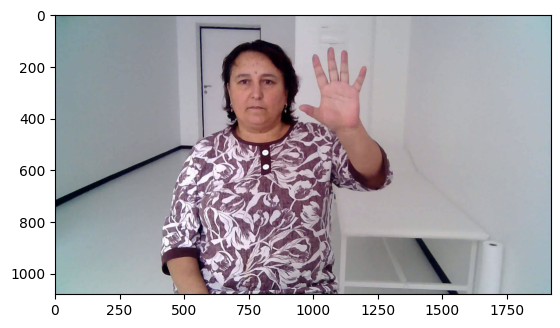

In [7]:
plt.imshow(img)

In [8]:
results = inference_topdown(model_pose, img)[0]

# Получить координату руки
keypoints = results.to_dict()["pred_instances"]["keypoints"][0]

RIGHT_HAND_IDX = 10
LEFT_HAND_IDX = 9

keypoints[RIGHT_HAND_IDX]

array([ 547.5, 1077.5], dtype=float32)

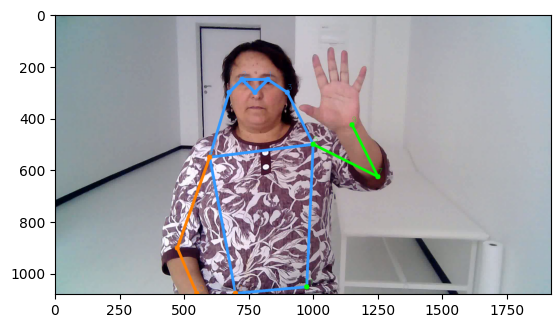

In [9]:
model_pose.cfg.visualizer.radius = sum(img.shape) // 300
model_pose.cfg.visualizer.alpha = 1.0
model_pose.cfg.visualizer.line_width = sum(img.shape) // 300

visualizer = VISUALIZERS.build(model_pose.cfg.visualizer)
visualizer.set_dataset_meta(model_pose.dataset_meta)

batch_results = inference_topdown(model_pose, img)
results = merge_data_samples(batch_results)

plt.imshow(
    visualizer.add_datasample(
            'result',
            img,
            data_sample=results,
            draw_gt=False,
            # draw_bbox=True,
            kpt_thr=0.5,
            # draw_heatmap=True,
            show_kpt_idx=True,
            # skeleton_style="mmpose",
            # show=True,
            # out_file="jopa.jpg",
    )
)

In [10]:
# Видео с pose estimation
def func(frame):
    batch_results = inference_topdown(model_pose, frame)
    results = merge_data_samples(batch_results)
    return visualizer.add_datasample(
        'result',
        frame,
        data_sample=results,
        draw_gt=False,
        # draw_bbox=True,
        kpt_thr=0.5,
        # draw_heatmap=True,
        show_kpt_idx=True,
        # skeleton_style="mmpose",
        # show=True,
        # out_file="jopa.jpg",
    )
show_video(video_path, func)

None

In [12]:
# Видео с вырезанием руки

HEIGHT = 500
WIDTH = 500

def func(frame):
    batch_results = inference_topdown(model_pose, frame)
    results = merge_data_samples(batch_results)

    keypoints = results.to_dict()["pred_instances"]["keypoints"][0]
    RIGHT_HAND_IDX = 10
    LEFT_HAND_IDX = 9
    x, y = keypoints[LEFT_HAND_IDX].astype(int)

    frame_cut = frame[
        y - HEIGHT // 2: y + HEIGHT // 2,
        x - WIDTH // 2: x + WIDTH // 2,
    ]
    return frame_cut
show_video(video_path, func)

None

# Сохранение видео

In [8]:
def save_video(frames: np.ndarray, output_path: str) -> None:
    """
    frames - кадры видео, размерность n*h*w*3, n - кол-во кадров
    """
    n, h, w, c = frames.shape
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    fps = 30
    frame_size = (w, h)
    out = cv2.VideoWriter(output_path, fourcc, fps, frame_size)
    for frame in frames:
        out.write(frame)
    out.release()

In [9]:
class Hand(Enum):
    LEFT = 1
    RIGHT = 2

    def get_keypoint_idx(self):
        return {Hand.LEFT: 9, Hand.RIGHT: 10}[self]

In [10]:
def pose_estimation(
    video_path: str,
) -> list:
    """Прогоняет pose estimation на видео и возвращает список с результатами по каждому кадру"""
    results = []
    pbar = tqdm.tqdm()
    video = cv2.VideoCapture(video_path)
    while True:
        ret, frame = video.read()
        if not ret:  # конец видео
            break

        batch_results = inference_topdown(model_pose, frame)
        results.append(merge_data_samples(batch_results))
        pbar.update(1)
    pbar.close()
    return results


def cut_hand_video(
    video_path: str,
    inference_results: list,
    hand: Hand,
    height: int = 500,
    width: int = 500,
) -> np.ndarray:
    """
    Вырезает руку из видео
    """
    video = cv2.VideoCapture(video_path)

    frames = []

    i = 0
    while True:
        ret, frame = video.read()
        if not ret:  # конец видео
            break

        results = inference_results[i]
        keypoints = results.to_dict()["pred_instances"]["keypoints"][0]
        
        x, y = keypoints[hand.get_keypoint_idx()].astype(int)

        frame_cut = frame[
            y - height // 2: y + height // 2,
            x - width // 2: x + width // 2,
        ]

        # Если кадр недостаточного размера, паддим
        h, w = frame_cut.shape[:2]
        pad_y = height - h
        pad_x = width - w
        frame_cut = np.pad(frame_cut, ((0, pad_y), (0, pad_x), (0, 0)))
        
        frames.append(frame_cut)
        i += 1
    return np.array(frames)

def get_moving_hand(
    inference_results: list,
) -> Hand:
    """Вычисляет руку, которая двигается по максимальной дисперсии координат"""
    left_hand_coords = []
    right_hand_coords = []
    for res in inference_results:
        keypoints = res.to_dict()["pred_instances"]["keypoints"][0]
        left_hand_coords.append(keypoints[Hand.LEFT.get_keypoint_idx()].astype(int))
        right_hand_coords.append(keypoints[Hand.RIGHT.get_keypoint_idx()].astype(int))
    left_hand_coords = np.array(left_hand_coords)
    right_hand_coords = np.array(right_hand_coords)
    left_std = left_hand_coords[:, 0].std() + left_hand_coords[:, 1].std()
    right_std = right_hand_coords[:, 0].std() + right_hand_coords[:, 1].std()
    if left_std > right_std:
        return Hand.LEFT
    return Hand.RIGHT

In [11]:
inference_results = pose_estimation(video_path)

0it [00:00, ?it/s]

In [12]:
hand = get_moving_hand(inference_results)

frames = cut_hand_video(
    video_path,
    inference_results,
    hand=hand,
)

In [13]:
frames.shape

(548, 500, 500, 3)

In [54]:
save_video(frames, "out.mp4")

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


# Ебашим весь датасет

In [14]:
dataset_path = pathlib.Path("hand dance")
cut_dataset_path = pathlib.Path("hands_cut")
cut_dataset_path.mkdir(exist_ok=True)

classes_folders = ["0", "1", "2", "3", "4"]

In [17]:
for cls in classes_folders:
    cls_folder = dataset_path / cls
    out_cls_folder = cut_dataset_path / cls
    out_cls_folder.mkdir(exist_ok=True)

    for video_path in cls_folder.glob("*"):
        out_video_path = out_cls_folder / video_path.name
        
        inference_results = pose_estimation(video_path)

        hand = get_moving_hand(inference_results)

        frames = cut_hand_video(
            video_path,
            inference_results,
            hand=hand,
        )

        save_video(frames, out_video_path)

0it [00:00, ?it/s]

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


0it [00:00, ?it/s]

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


0it [00:00, ?it/s]

...

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


0it [00:00, ?it/s]

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


0it [00:00, ?it/s]

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


# Предсказание рук

In [18]:
def hand_estimation(
    video_path: str,
) -> list:
    """Прогоняет hand estimation на видео и возвращает список с результатами по каждому кадру"""
    results = []
    pbar = tqdm.tqdm()
    video = cv2.VideoCapture(video_path)
    while True:
        ret, frame = video.read()
        if not ret:  # конец видео
            break

        batch_results = inference_topdown(model_hand, frame)
        results.append(merge_data_samples(batch_results))
        pbar.update(1)
    pbar.close()
    return results

In [19]:
res = hand_estimation(list((cut_dataset_path / "1").glob("*"))[0])

0it [00:00, ?it/s]

In [21]:
res[0]

<PoseDataSample(

    META INFORMATION
    input_center: array([250., 250.], dtype=float32)
    input_size: (256, 256)
    pad_shape: (256, 256)
    batch_input_shape: (256, 256)
    flip_indices: [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
    img_shape: (500, 500)
    input_scale: array([625., 625.], dtype=float32)
    img_path: None

    DATA FIELDS
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bbox_scores: array([1.], dtype=float32)
            bboxes: array([[  0.,   0., 500., 500.]], dtype=float32)
            rel_root_depth: array([18.60199], dtype=float32)
            keypoints_visible: array([[186.14493   , 200.06207   , 188.7355    , 185.45593   ,
                         99.86051   , 162.11852   , 188.3763    , 221.34052   ,
                         66.05002   , 105.492744  , 201.93648   , 2

# Посмотрим что получилось

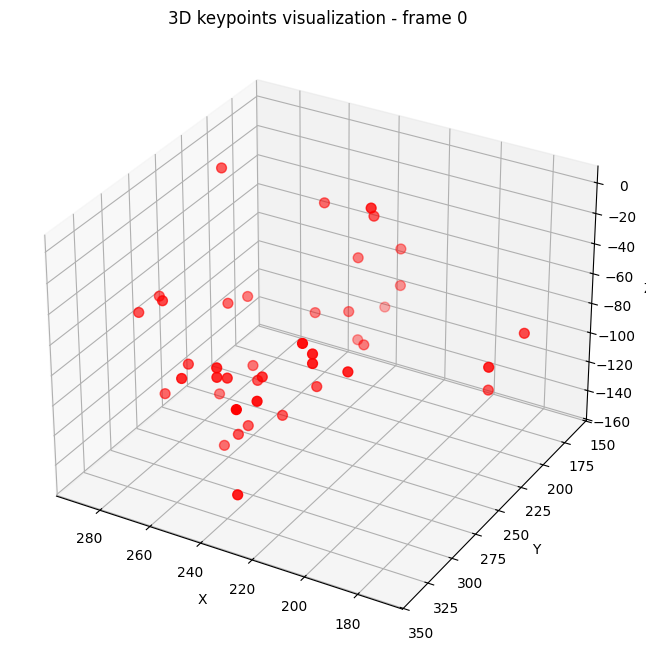

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # для 3D графика

# Путь к твоему csv
csv_path = r"C:\Users\maxim\p2025\keypoints_csv\0_100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4.csv"

# Загружаем данные
df = pd.read_csv(csv_path)

# Выведем для примера координаты из одного кадра (например, кадр 0)
frame_number = 0
frame_data = df[df['frame'] == frame_number]

# Извлекаем X, Y, Z для всех точек в кадре
xs = []
ys = []
zs = []

# Ключи в csv - по 3 на каждую точку: x_i, y_i, z_i
num_points = (len(frame_data.columns) - 1) // 3  # минус столбец "frame"

for i in range(num_points):
    xs.append(frame_data[f'x_{i}'].values[0])
    ys.append(frame_data[f'y_{i}'].values[0])
    zs.append(frame_data[f'z_{i}'].values[0])

# Визуализация
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(xs, ys, zs, c='r', s=50)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'3D keypoints visualization - frame {frame_number}')
ax.view_init(elev=30, azim=120)  # Можно вращать для удобного обзора

plt.show()


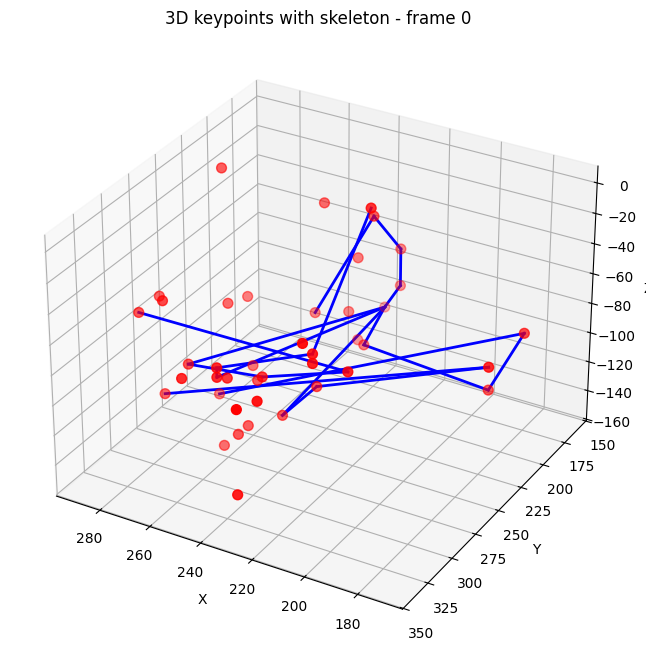

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

csv_path = r"C:\Users\maxim\p2025\keypoints_csv\0_100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4.csv"
df = pd.read_csv(csv_path)

frame_number = 0
frame_data = df[df['frame'] == frame_number]

num_points = (len(df.columns) - 1) // 3

xs = []
ys = []
zs = []
for i in range(num_points):
    xs.append(frame_data[f'x_{i}'].values[0])
    ys.append(frame_data[f'y_{i}'].values[0])
    zs.append(frame_data[f'z_{i}'].values[0])

connections = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9, 10), (10, 11), (11, 12),
    (0, 13), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20)
]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Точки
ax.scatter(xs, ys, zs, c='r', s=50)

# Линии между точками
for (start, end) in connections:
    ax.plot([xs[start], xs[end]], [ys[start], ys[end]], [zs[start], zs[end]], c='b', linewidth=2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'3D keypoints with skeleton - frame {frame_number}')
ax.view_init(elev=30, azim=120)

plt.show()
